In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [61]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


In [62]:
# Generate data paths with labels
def define_paths(dir):
    filepaths = []
    labels = []

    folds = os.listdir(dir)
    for fold in folds:
        foldpath = os.path.join(dir, fold)
        filelist = os.listdir(foldpath)

        for fold_ in filelist:
            foldpath_ = os.path.join(foldpath, fold_)
            filelist_ = os.listdir(foldpath_)

            for file_ in filelist_:
                fpath = os.path.join(foldpath_, file_)
                filepaths.append(fpath)
                labels.append(fold_)

    return filepaths, labels


# Concatenate data paths with labels into one dataframe ( to later be fitted into the model )
def define_df(files, classes):
    Fseries = pd.Series(files, name= 'filepaths')
    Lseries = pd.Series(classes, name='labels')
    return pd.concat([Fseries, Lseries], axis= 1)


# Function that create dataframe for train, validation, and test data
def create_df(data_dir):

    # train dataframe
    files, classes = define_paths(data_dir)
    df = define_df(files, classes)
    
    strat = df['labels']
    train_df, dummy_df = train_test_split(df, train_size=0.7, shuffle=True, random_state=123, stratify=strat)

    # test dataframe   
    strat = dummy_df['labels']
    valid_df, test_df= train_test_split(dummy_df, train_size=0.5, shuffle=True, random_state=123, stratify=strat)

    return train_df, valid_df, test_df

In [63]:
def create_model_data (train_df, valid_df, test_df, batch_size):
    '''
    This function takes train, validation, and test dataframe and fit them into image data generator, because model takes data from image data generator.
    Image data generator converts images into tensors. '''


    # define model parameters
    img_size = (224, 224)
    channels = 3 # either BGR or Grayscale
    color = 'rgb'
    img_shape = (img_size[0], img_size[1], channels)

    # Recommended : use custom function for test data batch size, else we can use normal batch size.
    ts_length = len(test_df)
    test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
    test_steps = ts_length // test_batch_size

    # This function which will be used in image data generator for data augmentation, it just take the image and return it again.
    def scalar(img):
        return img

    tr_gen = ImageDataGenerator(preprocessing_function= scalar, horizontal_flip= True)
    ts_gen = ImageDataGenerator(preprocessing_function= scalar)

    train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= True, batch_size= batch_size)

    valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= True, batch_size= batch_size)

    # Note: we will use custom test_batch_size, and make shuffle= false
    test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= False, batch_size= test_batch_size)

    return train_gen, valid_gen, test_gen

In [64]:
def show_images(gen):
    '''
    This function take the data generator and show sample of the images
    '''

    # return classes , images to be displayed
    g_dict = gen.class_indices        # defines dictionary {'class': index}
    classes = list(g_dict.keys())     # defines list of dictionary's kays (classes), classes names : string
    images, labels = next(gen)        # get a batch size samples from the generator

    # calculate number of displayed samples
    length = len(labels)        # length of batch size
    sample = min(length, 25)    # check if sample less than 25 images

    plt.figure(figsize= (20, 20))

    for i in range(sample):
        plt.subplot(5, 5, i + 1)
        image = images[i] / 255       # scales data to range (0 - 255)
        plt.imshow(image)
        index = np.argmax(labels[i])  # get image index
        class_name = classes[index]   # get class of image
        plt.title(class_name, color= 'blue', fontsize= 12)
        plt.axis('off')
    plt.show()

In [65]:
def plot_label_count(df, plot_title):
    '''
    This function take df and plot labels value counts
    '''

    # Define needed variables
    vcounts = df['labels'].value_counts()
    labels = vcounts.keys().tolist()
    values = vcounts.tolist()
    lcount = len(labels)

    if lcount > 55:
        print('The number of labels is > 55, no plot will be produced')

    else:
        plot_labels(lcount, labels, values, plot_title)

def plot_labels(lcount, labels, values, plot_title):
    width = lcount * 4
    width = np.min([width, 20])

    plt.figure(figsize= (width, 5))

    form = {'family': 'serif', 'color': 'blue', 'size': 25}
    sns.barplot(labels, values)
    plt.title(f'Images per Label in {plot_title} data', fontsize= 24, color= 'blue')
    plt.xticks(rotation= 90, fontsize= 18)
    plt.yticks(fontsize= 18)
    plt.xlabel('CLASS', fontdict= form)
    yaxis_label = 'IMAGE COUNT'
    plt.ylabel(yaxis_label, fontdict= form)

    rotation = 'vertical' if lcount >= 8 else 'horizontal'
    for i in range(lcount):
        plt.text(i, values[i] / 2, str(values[i]), fontsize= 12,
                rotation= rotation, color= 'yellow', ha= 'center')

    plt.show()

In [88]:
class MyCallback(keras.callbacks.Callback):
    def __init__(self, model, patience, stop_patience, threshold, factor, batches, epochs, ask_epoch):
        super(MyCallback, self).__init__()
        # Don't set self.model here - it's set automatically by Keras
        # Store a reference with a different name if needed
        self._model_ref = model
        self.patience = patience # specifies how many epochs without improvement before learning rate is adjusted
        self.stop_patience = stop_patience # specifies how many times to adjust lr without improvement to stop training
        self.threshold = threshold # specifies training accuracy threshold when lr will be adjusted based on validation loss
        self.factor = factor # factor by which to reduce the learning rate
        self.batches = batches # number of training batch to run per epoch
        self.epochs = epochs
        self.ask_epoch = ask_epoch
        self.ask_epoch_initial = ask_epoch # save this value to restore if restarting training

        # callback variables
        self.count = 0 # how many times lr has been reduced without improvement
        self.stop_count = 0
        self.best_epoch = 1   # epoch with the lowest loss
        self.initial_lr = float(model.optimizer.learning_rate.numpy() if hasattr(model.optimizer.learning_rate, 'numpy') else model.optimizer.learning_rate) # get the initial learning rate and save it
        self.highest_tracc = 0.0 # set highest training accuracy to 0 initially
        self.lowest_vloss = np.inf # set lowest validation loss to infinity initially
        self.best_weights = model.get_weights() # set best weights to model's initial weights
        self.initial_weights = model.get_weights()   # save initial weights if they have to get restored

    # Define a function that will run when train begins
    def on_train_begin(self, logs= None):
        msg = 'Do you want model asks you to halt the training [y/n] ?'
        print(msg)
        ans = input('')
        if ans in ['Y', 'y']:
            self.ask_permission = 1
        elif ans in ['N', 'n']:
            self.ask_permission = 0

        msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor','% Improv', 'Duration')
        print(msg)
        self.start_time = time.time()


    def on_train_end(self, logs= None):
        stop_time = time.time()
        tr_duration = stop_time - self.start_time
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))

        msg = f'training elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
        print(msg)

        # set the weights of the model to the best weights
        self.model.set_weights(self.best_weights)


    def on_train_batch_end(self, batch, logs= None):
        # get batch accuracy and loss
        acc = logs.get('accuracy') * 100
        loss = logs.get('loss')

        # prints over on the same line to show running batch count
        msg = '{0:20s}processing batch {1:} of {2:5s}-   accuracy=  {3:5.3f}   -   loss: {4:8.5f}'.format(' ', str(batch), str(self.batches), acc, loss)
        print(msg, '\r', end= '')


    def on_epoch_begin(self, epoch, logs= None):
        self.ep_start = time.time()


    # Define method runs on the end of each epoch
    def on_epoch_end(self, epoch, logs= None):
        ep_end = time.time()
        duration = ep_end - self.ep_start

        lr = float(self.model.optimizer.learning_rate.numpy() if hasattr(self.model.optimizer.learning_rate, 'numpy') else self.model.optimizer.learning_rate) # get the current learning rate
        current_lr = lr
        acc = logs.get('accuracy')  # get training accuracy
        v_acc = logs.get('val_accuracy')  # get validation accuracy
        loss = logs.get('loss')  # get training loss for this epoch
        v_loss = logs.get('val_loss')  # get the validation loss for this epoch

        if acc < self.threshold: # if training accuracy is below threshold adjust lr based on training accuracy
            monitor = 'accuracy'
            if epoch == 0:
                pimprov = 0.0
            else:
                pimprov = (acc - self.highest_tracc ) * 100 / self.highest_tracc # define improvement of model progres

            if acc > self.highest_tracc: # training accuracy improved in the epoch
                self.highest_tracc = acc # set new highest training accuracy
                self.best_weights = self.model.get_weights() # training accuracy improved so save the weights
                self.count = 0 # set count to 0 since training accuracy improved
                self.stop_count = 0 # set stop counter to 0
                if v_loss < self.lowest_vloss:
                    self.lowest_vloss = v_loss
                self.best_epoch = epoch + 1  # set the value of best epoch for this epoch

            else:
                # training accuracy did not improve check if this has happened for patience number of epochs
                # if so adjust learning rate
                if self.count >= self.patience - 1: # lr should be adjusted
                    lr = lr * self.factor # adjust the learning by factor
                    self.model.optimizer.learning_rate.assign(lr) # set the learning rate in the optimizer
                    self.count = 0 # reset the count to 0
                    self.stop_count = self.stop_count + 1 # count the number of consecutive lr adjustments
                    self.count = 0 # reset counter
                    if v_loss < self.lowest_vloss:
                        self.lowest_vloss = v_loss
                else:
                    self.count = self.count + 1 # increment patience counter

        else: # training accuracy is above threshold so adjust learning rate based on validation loss
            monitor = 'val_loss'
            if epoch == 0:
                pimprov = 0.0

            else:
                pimprov = (self.lowest_vloss - v_loss ) * 100 / self.lowest_vloss

            if v_loss < self.lowest_vloss: # check if the validation loss improved
                self.lowest_vloss = v_loss # replace lowest validation loss with new validation loss
                self.best_weights = self.model.get_weights() # validation loss improved so save the weights
                self.count = 0 # reset count since validation loss improved
                self.stop_count = 0
                self.best_epoch = epoch + 1 # set the value of the best epoch to this epoch

            else: # validation loss did not improve
                if self.count >= self.patience - 1: # need to adjust lr
                    lr = lr * self.factor # adjust the learning rate
                    self.stop_count = self.stop_count + 1 # increment stop counter because lr was adjusted
                    self.count = 0 # reset counter
                    self.model.optimizer.learning_rate.assign(lr) # set the learning rate in the optimizer

                else:
                    self.count = self.count + 1 # increment the patience counter

                if acc > self.highest_tracc:
                    self.highest_tracc = acc

        msg = f'{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^9.3f}{acc * 100:^9.3f}{v_loss:^9.5f}{v_acc * 100:^9.3f}{current_lr:^9.5f}{lr:^9.5f}{monitor:^11s}{pimprov:^10.2f}{duration:^8.2f}'
        print(msg)

        if self.stop_count > self.stop_patience - 1: # check if learning rate has been adjusted stop_count times with no improvement
            msg = f' training has been halted at epoch {epoch + 1} after {self.stop_patience} adjustments of learning rate with no improvement'
            print(msg)
            self.model.stop_training = True # stop training

        else:
            if self.ask_epoch != None and self.ask_permission != 0:
                if epoch + 1 >= self.ask_epoch:
                    msg = 'enter H to halt training or an integer for number of epochs to run then ask again'
                    print(msg)

                    ans = input('')
                    if ans == 'H' or ans == 'h':
                        msg = f'training has been halted at epoch {epoch + 1} due to user input'
                        print(msg)
                        self.model.stop_training = True # stop training

                    else:
                        try:
                            ans = int(ans)
                            self.ask_epoch += ans
                            msg = f' training will continue until epoch {str(self.ask_epoch)}'
                            print(msg)
                            msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor', '% Improv', 'Duration')
                            print(msg)

                        except Exception:
                            print('Invalid')

In [67]:
def plot_training(hist):
    '''
    This function take training model and plot history of accuracy and losses with the best epoch in both of them.
    '''

    # Define needed variables
    tr_acc = hist.history['accuracy']
    tr_loss = hist.history['loss']
    val_acc = hist.history['val_accuracy']
    val_loss = hist.history['val_loss']
    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]
    Epochs = [i+1 for i in range(len(tr_acc))]
    loss_label = f'best epoch= {str(index_loss + 1)}'
    acc_label = f'best epoch= {str(index_acc + 1)}'

    # Plot training history
    plt.figure(figsize= (20, 8))
    plt.style.use('fivethirtyeight')

    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
    plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
    plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
    plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout
    plt.show()

In [68]:
def plot_confusion_matrix(cm, classes, normalize= False, title= 'Confusion Matrix', cmap= plt.cm.Blues):
	'''
	This function plot confusion matrix method from sklearn package.
	'''

	plt.figure(figsize= (10, 10))
	plt.imshow(cm, interpolation= 'nearest', cmap= cmap)
	plt.title(title)
	plt.colorbar()

	tick_marks = np.arange(len(classes))
	plt.xticks(tick_marks, classes, rotation= 45)
	plt.yticks(tick_marks, classes)

	if normalize:
		cm = cm.astype('float') / cm.sum(axis= 1)[:, np.newaxis]
		print('Normalized Confusion Matrix')

	else:
		print('Confusion Matrix, Without Normalization')

	print(cm)

	thresh = cm.max() / 2.
	for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
		plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

	plt.tight_layout()
	plt.ylabel('True Label')
	plt.xlabel('Predicted Label')

In [69]:
data_dir = '/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data'

try:
    # Get splitted data
    train_df, valid_df, test_df = create_df(data_dir)

    # Get Generators
    batch_size = 40
    train_gen, valid_gen, test_gen = create_model_data(train_df, valid_df, test_df, batch_size)

except:
    print('Invalid Input')

Found 7462 validated image filenames belonging to 2 classes.
Found 1599 validated image filenames belonging to 2 classes.
Found 1600 validated image filenames belonging to 2 classes.


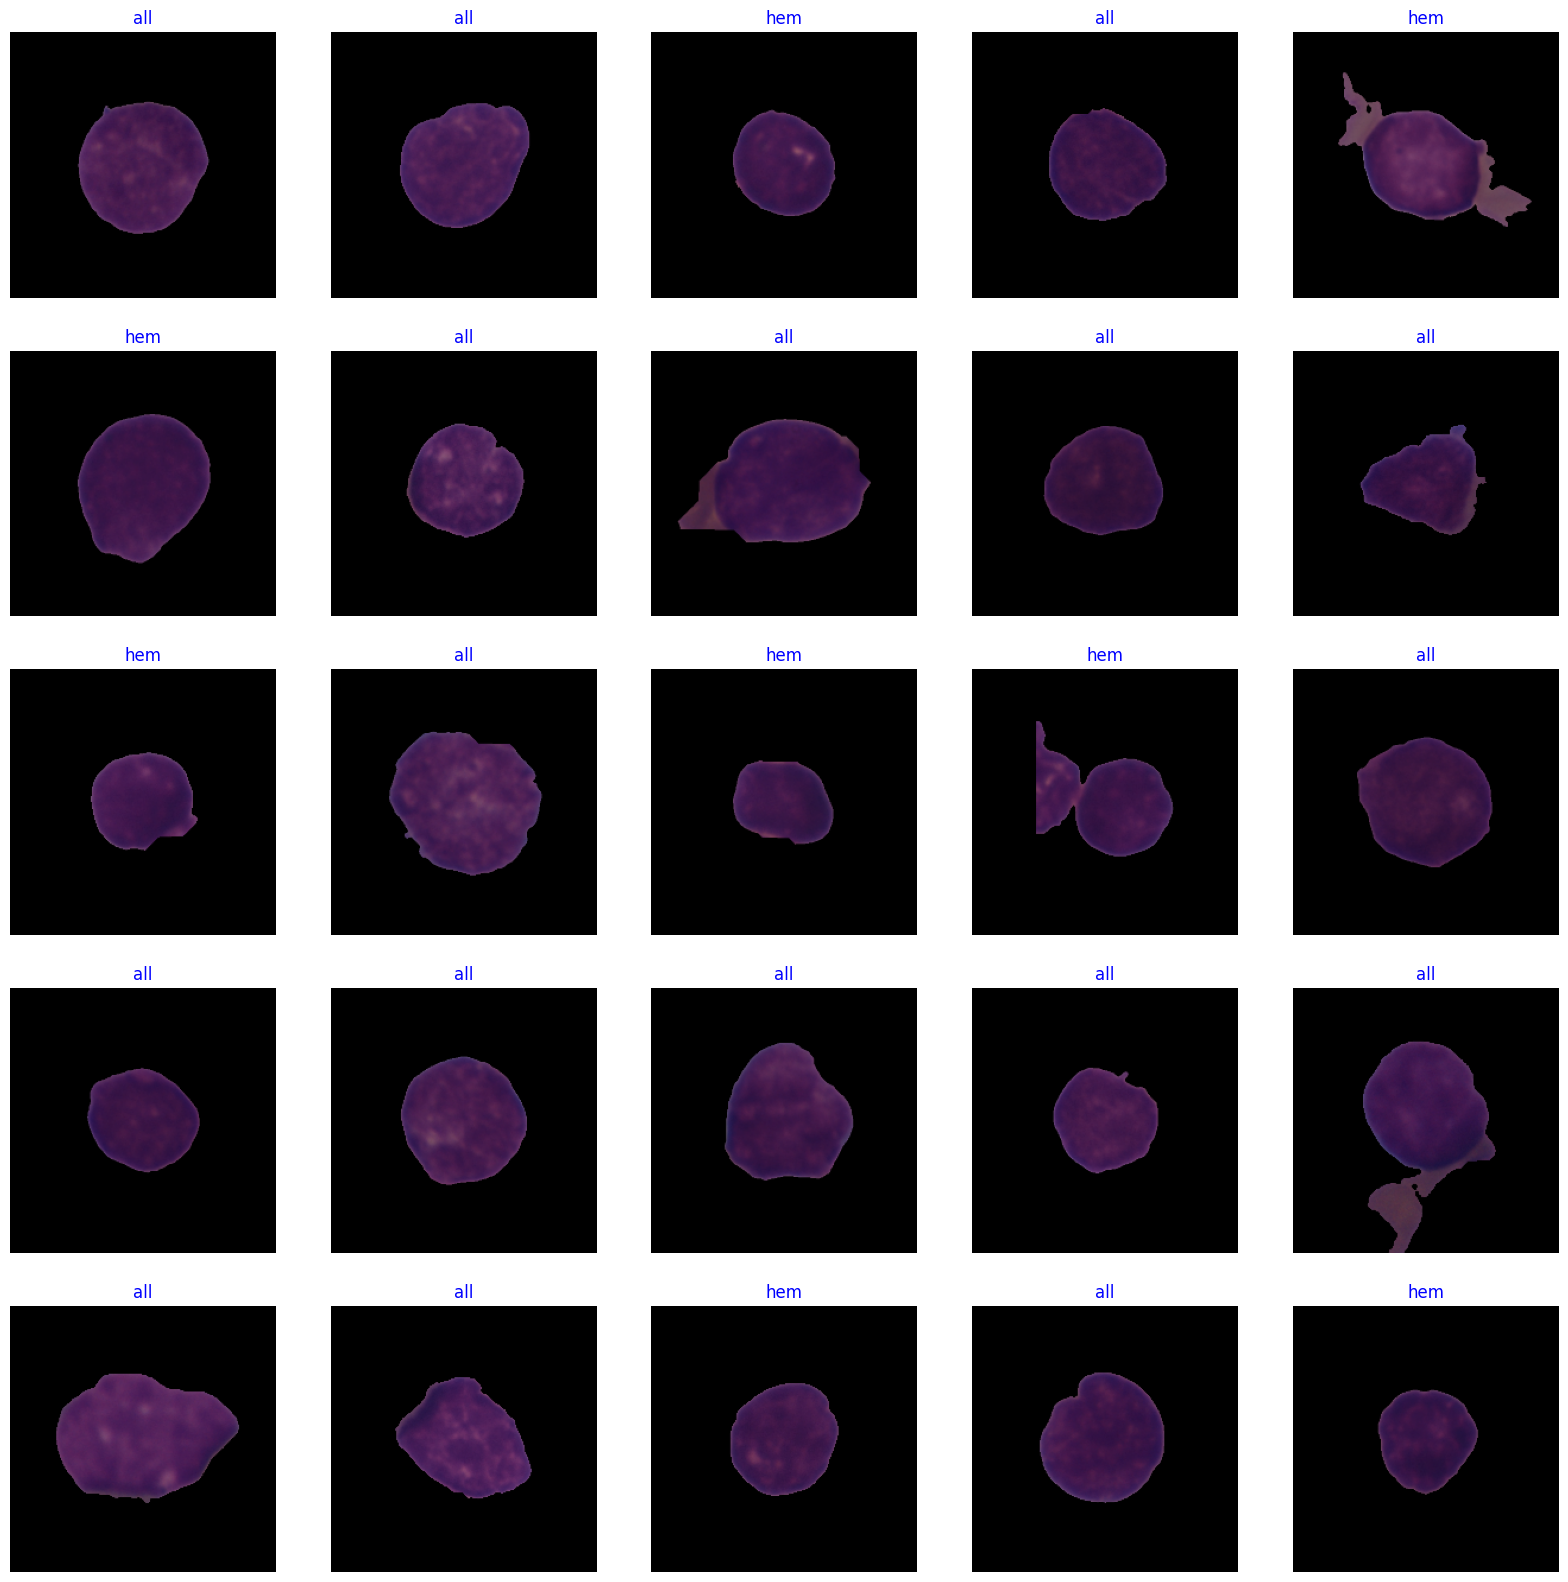

In [70]:
show_images(train_gen)

In [92]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout
from sklearn.utils import class_weight
import numpy as np

# Create Model Structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys()))

# ============================================
# CRITICAL: Calculate class weights
# ============================================
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights_dict = dict(enumerate(class_weights))

print("Class weights to handle imbalance:")
for cls, weight in class_weights_dict.items():
    print(f"  Class {cls}: {weight:.3f}")

# ============================================
# STAGE 1: Train top layers (frozen base)
# ============================================
print("\n" + "="*60)
print("STAGE 1: Training classifier with frozen base")
print("="*60)

base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling='max'
)

base_model.trainable = False

model = Sequential([
    base_model,
    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
    # REDUCED regularization dramatically
    Dense(256, kernel_regularizer=regularizers.l2(0.001),  # Was 0.016
          activity_regularizer=regularizers.l1(0.0001),    # Was 0.006
          bias_regularizer=regularizers.l1(0.0001),        # Was 0.006
          activation='relu'),
    # REDUCED dropout
    Dropout(rate=0.3, seed=123),  # Was 0.45
    Dense(class_count, activation='softmax')
])

model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

# Train stage 1 with class weights
print("Training with class weights to handle imbalance...")
history_stage1 = model.fit(
    train_gen,
    epochs=15,
    validation_data=valid_gen,
    class_weight=class_weights_dict,  # CRITICAL: Handle class imbalance
    verbose=1
)

# ============================================
# STAGE 2: Fine-tune with unfrozen layers
# ============================================
print("\n" + "="*60)
print("STAGE 2: Fine-tuning with unfrozen layers")
print("="*60)

# Unfreeze the last 50 layers
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Count trainable parameters
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable parameters: {trainable_params:,}")

# Recompile with lower learning rate
model.compile(
    optimizer=Adamax(learning_rate=0.00005),  # Even lower for fine-tuning
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

# Updated callback with better parameters
callbacks = [MyCallback(
    model=model,
    patience=5,        # More patience
    stop_patience=4,   # More chances
    threshold=0.75,    # Lower threshold (was 0.9)
    factor=0.5,
    batches=len(train_gen),
    epochs=50,
    ask_epoch=25
)]

# Train with class weights
history_stage2 = model.fit(
    train_gen,
    epochs=50,
    validation_data=valid_gen,
    callbacks=callbacks,
    class_weight=class_weights_dict,  # CRITICAL: Keep using class weights
    verbose=0
)

print("\n" + "="*60)
print("Training complete!")
print("="*60)

Class weights to handle imbalance:
  Class 0: 0.733
  Class 1: 1.573

STAGE 1: Training classifier with frozen base
Training with class weights to handle imbalance...
Epoch 1/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 84s 245ms/step - accuracy: 0.6909 - loss: 1.6106 - val_accuracy: 0.7774 - val_loss: 1.1380
Epoch 2/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.7797 - loss: 1.1527 - val_accuracy: 0.7880 - val_loss: 0.9714
Epoch 3/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.7881 - loss: 1.0099 - val_accuracy: 0.7986 - val_loss: 0.8766
Epoch 4/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 18s 95ms/step - accuracy: 0.7966 - loss: 0.9048 - val_accuracy: 0.8255 - val_loss: 0.7966
Epoch 5/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - accuracy: 0.8230 - loss: 0.8057 - val_accuracy: 0.8199 - val_loss: 0.7637
Epoch 6/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.8163 - loss: 0.7721 - val_accuracy: 0.8293 - val_loss: 0.7215
Epoch 7/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 19s 100m

 y


 Epoch     Loss   Accuracy  V_loss    V_acc     LR     Next LR  Monitor  % Improv  Duration
 1 /50     0.700   78.813   0.63663  82.051   0.00005  0.00005  val_loss     0.00    103.22 
 2 /50     0.658   81.171   0.62737  82.114   0.00005  0.00005  val_loss     1.46    17.27  
 3 /50     0.633   82.150   0.61915  82.739   0.00005  0.00005  val_loss     1.31    17.69  
 4 /50     0.622   81.895   0.59976  83.802   0.00005  0.00005  val_loss     3.13    17.63  
 5 /50     0.609   83.235   0.59647  84.053   0.00005  0.00005  val_loss     0.55    17.87  
 6 /50     0.596   83.637   0.59570  83.990   0.00005  0.00005  val_loss     0.13    17.99  
 7 /50     0.581   84.026   0.59312  84.678   0.00005  0.00005  val_loss     0.43    19.11  
 8 /50     0.584   84.455   0.58360  84.615   0.00005  0.00005  val_loss     1.60    17.97  
 9 /50     0.576   84.964   0.57480  84.678   0.00005  0.00005  val_loss     1.51    17.56  
10 /50     0.565   85.165   0.57021  85.241   0.00005  0.00005  val_los

 7


 training will continue until epoch 32
 Epoch     Loss   Accuracy  V_loss    V_acc     LR     Next LR  Monitor  % Improv  Duration
26 /50     0.483   89.386   0.54529  86.179   0.00002  0.00002  val_loss    -0.25    18.98  
27 /50     0.480   89.292   0.53745  87.179   0.00002  0.00002  val_loss     1.19    17.96  
28 /50     0.482   89.038   0.54472  86.617   0.00002  0.00002  val_loss    -1.35    18.35  
29 /50     0.477   89.266   0.54046  86.742   0.00002  0.00002  val_loss    -0.56    17.42  
30 /50     0.467   90.003   0.54690  86.179   0.00002  0.00002  val_loss    -1.76    17.13  
31 /50     0.472   89.721   0.53720  87.117   0.00002  0.00002  val_loss     0.05    17.68  
32 /50     0.474   89.627   0.53995  86.804   0.00002  0.00002  val_loss    -0.51    19.02  
enter H to halt training or an integer for number of epochs to run then ask again


 H


training has been halted at epoch 32 due to user input
training elapsed time was 0.0 hours, 12.0 minutes, 42.34 seconds)

Training complete!


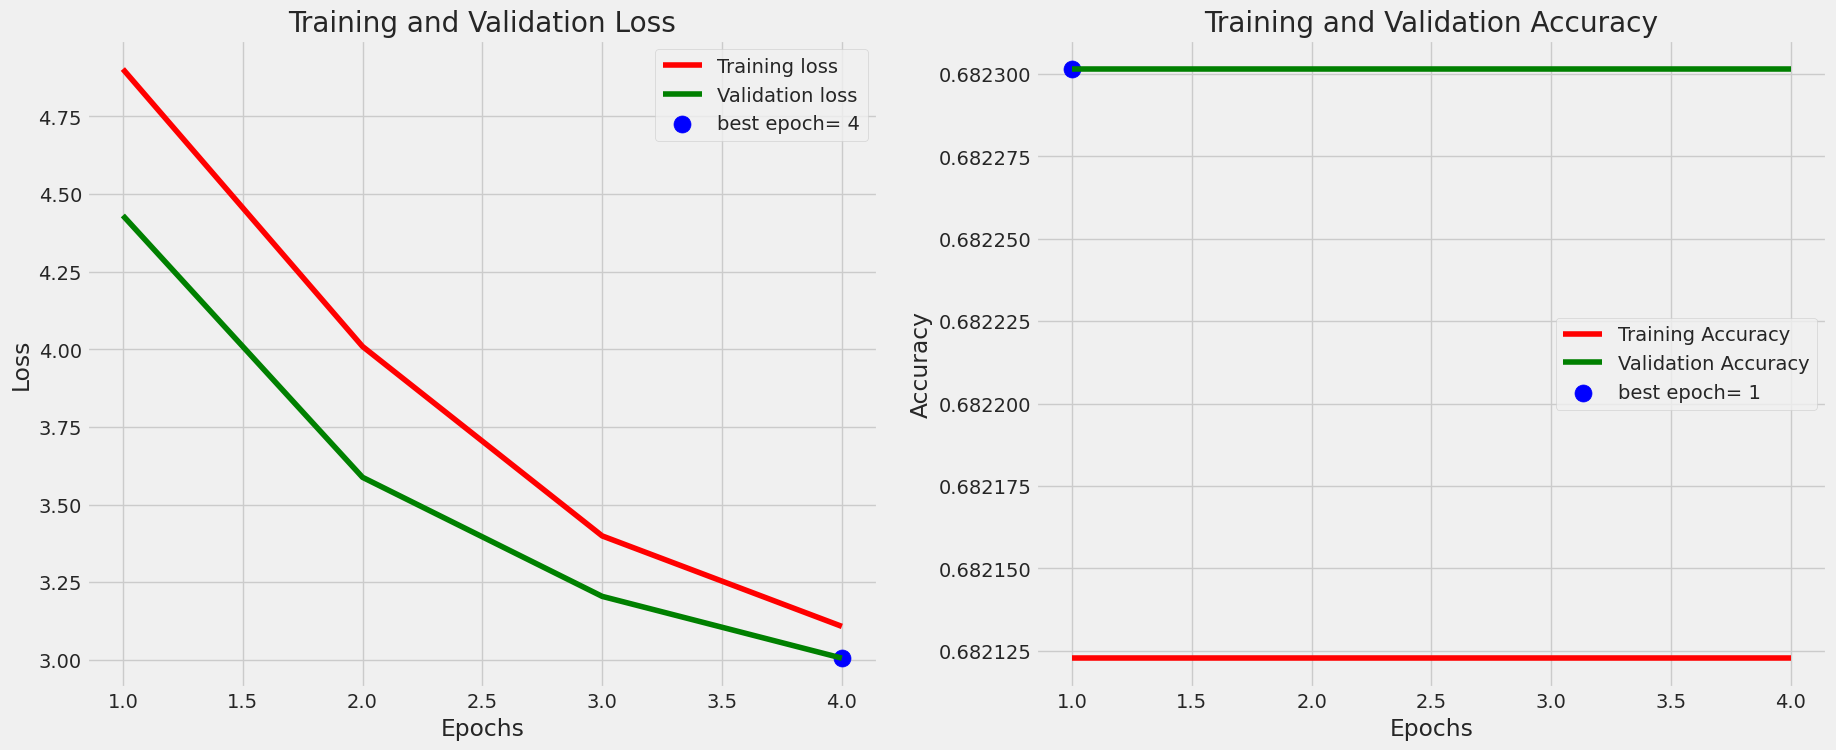

In [94]:
plot_training(history)

In [95]:
ts_length = len(test_df)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.9534 - loss: 0.3549
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8886 - loss: 0.4946
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 807ms/step - accuracy: 0.8753 - loss: 0.5895
Train Loss:  0.3659970462322235
Train Accuracy:  0.9474999904632568
--------------------
Validation Loss:  0.5329700708389282
Validation Accuracy:  0.8737499713897705
--------------------
Test Loss:  0.581621527671814
Test Accuracy:  0.875


In [100]:
# Ensure the model is built
model.build(input_shape=(None, img_size[0], img_size[1], channels))

# Alternatively, access input layer name directly from the first layer
model_name = model.layers[0].input.name.split(':')[0]  # Extracting the input layer name
subject = input('Enter Project Subject')
acc = test_score[1] * 100
save_path = ''

# Save model
save_id = str(f'{model_name}-{subject}-{"%.2f" %round(acc, 2)}.h5')
model_save_loc = os.path.join(save_path, save_id)
model.save(model_save_loc)
print(f'model was saved as {model_save_loc}')

# Save weights
# Ensure the filename ends with .weights.h5 for saving weights
weight_save_id = str(f'{model_name}-{subject}-weights.weights.h5')
weights_save_loc = os.path.join(save_path, weight_save_id)

# Save weights with corrected filename
model.save_weights(weights_save_loc)
print(f'weights were saved as {weights_save_loc}')


Enter Project Subject lukemia detection 


model was saved as keras_tensor_4300-lukemia detection -87.50.h5
weights were saved as keras_tensor_4300-lukemia detection -weights.weights.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


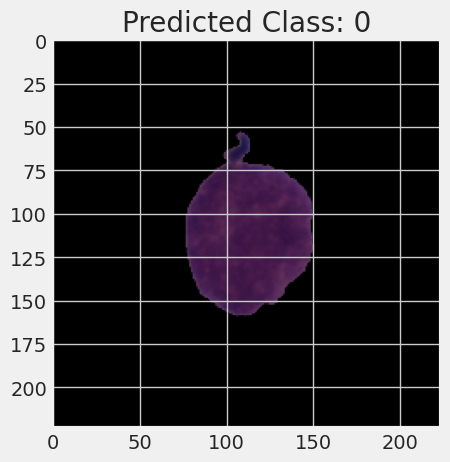

Predicted Class: 0


In [108]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load the model (replace with your saved model path)
model = tf.keras.models.load_model('/kaggle/working/keras_tensor_4300-lukemia detection -87.50.h5')

# Define the input size your model expects
img_size = (224, 224)  # Make sure this matches the input size of your model

# Function to preprocess the image and make predictions
def predict_image(img_path):
    # Load the image and resize it to the input size expected by the model
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)  # Convert the image to a numpy array
    img_array = np.expand_dims(img_array, axis=0)  # Add the batch dimension
    img_array = img_array / 255.0  # Normalize the image if the model was trained on normalized data
    
    # Make the prediction
    prediction = model.predict(img_array)
    
    # Get the predicted class (assuming you're using softmax)
    predicted_class = np.argmax(prediction, axis=-1)
    
    # Plot the image and display the prediction
    plt.imshow(img)
    plt.title(f'Predicted Class: {predicted_class[0]}')
    plt.show()
    
    return predicted_class[0], prediction

# Example usage:
img_path = '/kaggle/input/leukemia-classification/C-NMC_Leukemia/testing_data/C-NMC_test_final_phase_data/1.bmp'  # Replace with the path to your test image
predicted_class, prediction = predict_image(img_path)

print(f"Predicted Class: {predicted_class}")
